## Overview

for different models

1) Plot loss vs epochs through training process on same season

2) predict data of one test season, but training was different

----
## Data:

-2D Space - Timeseries

-predicting 1 feature out of 7 variables

-Forecasting 1 timestep (not the following)

-------
Peter Resch, 6.6.

In [43]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np
import os
from pathlib import Path

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split

import xarray as xr

from my_dataloader_module import TimeseriesDatasetPipeline, TimeseriesPyTorchDataset

rSeed=42

SavePlots = False

## Loading Data

In [47]:
working_dir="models"#"../../../datasets/small_grid"
image_folder="../images"
!cd {working_dir} && ls

GRU				    losses_cnn_gru_recent_autumn.csv
losses_cnn_gru_combined_autumn.csv  losses_cnn_gru_recent_spring.csv
losses_cnn_gru_combined_spring.csv  losses_cnn_gru_recent_summer.csv
losses_cnn_gru_combined_summer.csv  losses_cnn_gru_recent_winter.csv
losses_cnn_gru_combined_winter.csv  losses_cnn_lstm_tuned_combined_autumn.csv
losses_cnn_gru_past_autumn.csv	    losses_cnn_lstm_tuned_combined_spring.csv
losses_cnn_gru_past_spring.csv	    losses_cnn_lstm_tuned_combined_summer.csv
losses_cnn_gru_past_summer.csv	    losses_cnn_lstm_tuned_combined_winter.csv
losses_cnn_gru_past_winter.csv	    LSTM-HPT


In [48]:
past="recent_"#"past_"#
model="gru" #"lstm"#
#-------------------------------


seasons={"spring": "MAM", "summer": "JJA", "autumn": "SON", "winter": "DJF"}

filelist = [p.name for p in Path(working_dir).iterdir() if p.is_file()]
filelist = [f for f in filelist if f.endswith('.csv')]
filelist.sort()
print(filelist)

['losses_cnn_gru_combined_autumn.csv', 'losses_cnn_gru_combined_spring.csv', 'losses_cnn_gru_combined_summer.csv', 'losses_cnn_gru_combined_winter.csv', 'losses_cnn_gru_past_autumn.csv', 'losses_cnn_gru_past_spring.csv', 'losses_cnn_gru_past_summer.csv', 'losses_cnn_gru_past_winter.csv', 'losses_cnn_gru_recent_autumn.csv', 'losses_cnn_gru_recent_spring.csv', 'losses_cnn_gru_recent_summer.csv', 'losses_cnn_gru_recent_winter.csv', 'losses_cnn_lstm_tuned_combined_autumn.csv', 'losses_cnn_lstm_tuned_combined_spring.csv', 'losses_cnn_lstm_tuned_combined_summer.csv', 'losses_cnn_lstm_tuned_combined_winter.csv']


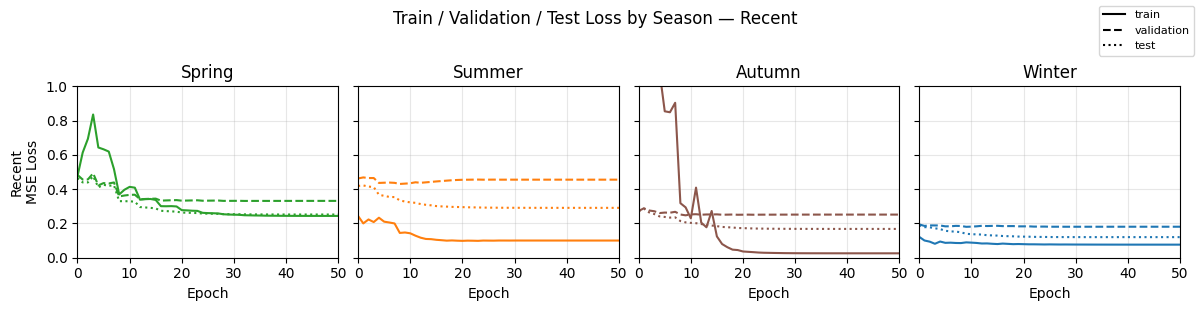

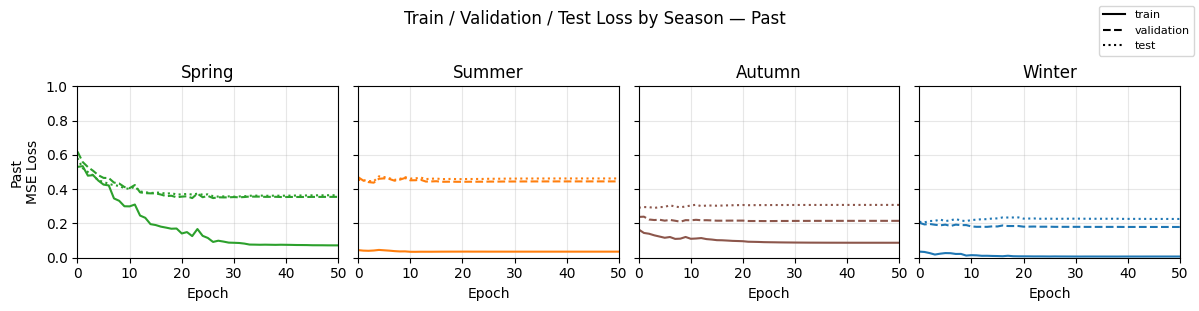

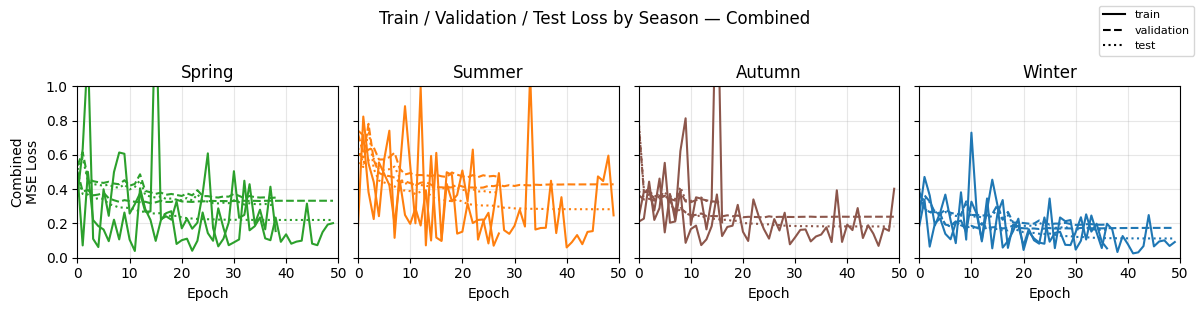

<Figure size 640x480 with 0 Axes>

In [49]:
categories = ["recent", "past", "combined"]

season_order = ["spring", "summer", "autumn", "winter"]

for i, category in enumerate(categories):
    # per-category individual figure (1x4)
    fig_cat, axs = plt.subplots(1, len(season_order), figsize=(12, 3), sharey=True)
    axs = axs if isinstance(axs, (np.ndarray, list)) else [axs]

    for j, season_key in enumerate(season_order):
        ax_row_col = axes_all[i, j]
        axc = axs[j]

        for fname in filelist:
            lf = fname.lower()
            if season_key not in lf:
                continue
            if f"_{category}_" not in lf:
                continue

            path = Path(working_dir) / fname
            loss_df = pd.read_csv(path)

            line_color = season_colors.get(season_key, "tab:gray")
            epochs = np.arange(len(loss_df))

            # plot on combined grid
            ax_row_col.plot(epochs, loss_df[train_col], color=line_color, linestyle=loss_styles["train"])
            ax_row_col.plot(epochs, loss_df[val_col], color=line_color, linestyle=loss_styles["validation"])
            ax_row_col.plot(epochs, loss_df[test_col], color=line_color, linestyle=loss_styles["test"])

            # plot on per-category figure
            axc.plot(epochs, loss_df[train_col], color=line_color, linestyle=loss_styles["train"])
            axc.plot(epochs, loss_df[val_col], color=line_color, linestyle=loss_styles["validation"])
            axc.plot(epochs, loss_df[test_col], color=line_color, linestyle=loss_styles["test"])

        # common formatting
        for ax in (ax_row_col, axc):
            ax.set_title(season_key.capitalize())
            if j == 0:
                ax.set_ylabel(f"{category.capitalize()}\nMSE Loss")
            ax.set_xlabel("Epoch")
            ax.set_ylim(0, 1)
            ax.set_xlim(0, 50)
            ax.grid(True, alpha=0.3)

    # legend & title for per-category fig
    handles = [
        plt.Line2D([], [], color="k", linestyle=loss_styles["train"], label="train"),
        plt.Line2D([], [], color="k", linestyle=loss_styles["validation"], label="validation"),
        plt.Line2D([], [], color="k", linestyle=loss_styles["test"], label="test"),
    ]
    fig_cat.legend(handles=handles, loc="upper right", fontsize=8)
    fig_cat.suptitle(f"Train / Validation / Test Loss by Season — {category.capitalize()}", y=1.02)
    plt.tight_layout()

    if SavePlots:
        out_path = Path(image_folder) / f"loss_curves_{category}.png"
        fig_cat.savefig(out_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig_cat)

# finalize combined figure
fig_all.legend(handles=handles, loc="upper right", fontsize=9)
fig_all.suptitle("Train / Validation / Test Loss by Season — Recent / Past / All", y=1.02)
plt.tight_layout()
if SavePlots:
    out_path = Path(image_folder) / "loss_curves_all_categories.png"
    fig_all.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
